# Experiment 2 — Feature family and model comparison

**Paper reference:** Appendix B.1 (v7 spec), Tables 3–4 plus the Candidate
Feature Map × Candidate Model × Model Selection pipeline.

**Goal.** For each of the six seller policies, identify the best
combination of (feature map, estimator) under grouped 10-fold CV, using the
two-stage selection rule:

1. **Stage 1 (1-SE rule).** Among all (feature, model) candidates, retain
   those whose normalized MAE lies within one standard error of the best
   candidate for that policy.
2. **Stage 2 (parsimony).** Among the Stage-1 survivors that are linear
   (OLS / Ridge), pick the one with the smallest $\dim(\phi)$, then the
   smallest lag order $\tau$, then the smallest standardized $\|\theta\|_1$.

The output of this notebook is the *canonical linear policy approximation*
that every downstream appendix experiment (Exp 3–16) uses.

**Data filtering (v7 spec):**
- Truncate $S_t$ to $[v, M]$;
- drop all turns *after* the first agreement turn (first $t$ with $S_t \le 1.01 B_t$);
- restrict modelling to rounds $3 \le t \le 12$ (stabilized region);
- target is $Y_t = \operatorname{logit}(\operatorname{clip}(\tilde S_t, \eta, 1-\eta))$
  with $\eta = 10^{-4}$, predictions mapped back via $\sigma(\cdot)$;
  the `Base` predictor alone is fit on $\tilde S_t$ directly.

## 1. Setup

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import negolin_utils as nu
nu.setup_matplotlib()

# If your data lives somewhere else, override:
nu.RAND_BUYER_DIR = Path('../0421_redo_previous_exp/results')
DATA_DIR = nu.RAND_BUYER_DIR
print('Data dir:', DATA_DIR)

Data dir: ..\0421_redo_previous_exp\results


## 2. Load data and apply preprocessing

In [2]:
raw = nu.load_all_fixed_policies(DATA_DIR)
runs_per_policy = raw.groupby('policy')['run_id'].nunique().to_dict()
print(f'Raw turns: {len(raw):,}   runs per policy: {runs_per_policy}')

all_marked, turns = nu.preprocess_turns(raw)
n_post_ag = int(all_marked['after_agreement'].sum())
print(f'Post-agreement dropped: {n_post_ag:,}')
print(f'Analysis turns (parse-failure rows retained for lag alignment): {len(turns):,}')

Raw turns: 14,400   runs per policy: {'FRB': 150, 'IC': 150, 'MEVJ': 150, 'OADS': 150, 'PVD': 150, 'RFK': 150}
Post-agreement dropped: 8,148
Analysis turns (parse-failure rows retained for lag alignment): 6,252


## 3. Table 3 — pooled turn counts by policy × vehicle

Clean (parse-success) turns only, after truncation and the agreement
cut-off.  This is the denominator for everything downstream.

In [3]:
POLICY_ORDER   = list(nu.POLICIES)
VEHICLE_COLS   = [f'Vehicle {i}' for i in range(1, 6)]

table3 = (turns[~turns['parse_fail']]
            .groupby(['policy', 'vehicle']).size()
            .unstack('vehicle')
            .reindex(index=POLICY_ORDER, columns=VEHICLE_COLS)
            .fillna(0).astype(int))
table3['Total'] = table3.sum(axis=1)
table3.loc['Total'] = table3.sum(axis=0)
table3

vehicle,Vehicle 1,Vehicle 2,Vehicle 3,Vehicle 4,Vehicle 5,Total
policy,,,,,,
PVD,233,216,225,223,144,1041
IC,229,214,225,222,144,1034
FRB,233,215,226,223,144,1041
RFK,233,216,224,223,144,1040
OADS,231,215,226,221,143,1036
MEVJ,233,216,226,223,144,1042
Total,1392,1292,1352,1335,863,6234


## 4. Table 4 — truncation proportions

Percentages are computed relative to the turn counts in Table 3.

In [4]:
clean = turns[~turns['parse_fail']]
lo = (clean.groupby(['policy','vehicle'])['lower_truncated'].mean() * 100
          ).unstack('vehicle').reindex(index=POLICY_ORDER, columns=VEHICLE_COLS).round(1)
up = (clean.groupby(['policy','vehicle'])['upper_truncated'].mean() * 100
          ).unstack('vehicle').reindex(index=POLICY_ORDER, columns=VEHICLE_COLS).round(1)

table4 = pd.concat({'S_t < v (%)': lo, 'S_t > M (%)': up}, axis=1)
table4

S_t < v (%)                                         S_t > M (%)  \
vehicle   Vehicle 1 Vehicle 2 Vehicle 3 Vehicle 4 Vehicle 5   Vehicle 1   
policy                                                                    
PVD             1.7       4.6       0.0       0.0       0.0         0.0   
IC              1.7       3.7       1.8       2.3       0.0         0.0   
FRB             0.0       7.4       2.2       1.3       1.4         0.0   
RFK             0.0       1.9       0.0       0.0       0.0         0.9   
OADS            0.4       9.3       0.4       2.7       2.8         0.0   
MEVJ            0.0       1.4       0.0       0.0       0.0         0.0   

                                                 
vehicle Vehicle 2 Vehicle 3 Vehicle 4 Vehicle 5  
policy                                           
PVD           0.0       0.0       0.9       1.4  
IC            0.0       0.0       0.0       1.4  
FRB           0.0       0.9       0.0       0.7  
RFK           0.0       1.3       0.0       1.4  
OADS          0.0       0.0       0.5       0.0  
MEVJ          0.0       0.9       0.0       1.4

## 5. Candidate feature maps

Ten specifications in the v7 notation, plus a `Base` predictor
($\tilde S_t \approx \theta_0 + \theta_1 \tilde S_{t-1}$) that serves as a
null benchmark.

In [5]:
feat_summary = nu.feature_summary_table()
feat_summary

,feature,description,lag_order,dim_phi
0,I,"(1, B_t)",0,2
1,II,"(1, B_t, S_{t-1}, B_{t-1})",1,4
2,III,"(1, B_t, S_{t-1}, B_{t-1}, S_{t-2}, B_{t-2})",2,6
3,IV,"(1, A_t, S_{t-1})",1,3
4,V,"(1, A_t, S_{t-1}, A_{t-1}, S_{t-2})",2,5
5,VI,"(1, B_t^+, B_t^-)",0,3
6,VII,"(1, B_t^+, B_t^-, S_{t-1}, B_{t-1}^+, B_{t-1}^-)",1,6
7,VIII,"(1, B_t, S_{t-1}, dB_t)",1,4
8,IX,"(1, B_t^+, B_t^-, S_{t-1}, dB_t^+, dB_t^-)",1,6
9,X,"(1, B_t^+, B_t^-, S_{t-1}, dB_t^+, dB_t^-, dS_...",2,8


## 6. Full model grid

$6$ policies $\times$ $10$ feature maps $\times$ $5$ models $+$ the Base
baseline per policy $= 306$ model fits under grouped 10-fold CV stratified
by vehicle.  This cell is the most expensive — expect several minutes on
a laptop.  To shorten the run, drop MLP or GAM from `MODELS` below.

In [6]:
import time
# MODELS = ['Base', 'OLS', 'Ridge', 'GAM', 'GBR', 'MLP']
# To speed up development, drop MLP/GAM:
MODELS = ['Base', 'OLS', 'Ridge', 'GBR']

grid_rows = []
oof_store = {}          # keyed by (policy, feature, model) -> pred_df
t0 = time.time()

for policy in POLICY_ORDER:
    # --- Base baseline (only feature is S_lag1, fit on normalized scale) ---
    meta_b, Xb, yb, cb = nu.build_design_matrix(turns, policy, 'Base')
    pred_b, _ = nu.grouped_cv_predict(meta_b, Xb, yb, 'Base', n_splits=nu.OUTER_FOLDS)
    m = nu.cv_metrics_full(pred_b)
    grid_rows.append({'policy': policy, 'feature': 'Base', 'model': 'Base',
                      'alpha': np.nan, **m})
    oof_store[(policy, 'Base', 'Base')] = pred_b

    # --- I..X on every non-Base model ---
    for feat_name in nu.FEATURE_SPECS_V7.keys():
        meta, X, y, cols = nu.build_design_matrix(turns, policy, feat_name)
        if len(X) < 100:
            continue
        for model_name in MODELS[1:]:
            pred, alphas = nu.grouped_cv_predict(meta, X, y, model_name,
                                                  n_splits=nu.OUTER_FOLDS)
            m = nu.cv_metrics_full(pred)
            alpha_med = float(np.nanmedian(alphas)) if any(np.isfinite(alphas)) else np.nan
            grid_rows.append({'policy': policy, 'feature': feat_name,
                              'model': model_name, 'alpha': alpha_med, **m})
            oof_store[(policy, feat_name, model_name)] = pred
    n_done = sum(1 for k in oof_store if k[0] == policy)
    print(f'  {policy}: {n_done} evaluations done   elapsed: {time.time()-t0:.0f}s')

model_grid = pd.DataFrame(grid_rows)
print(f'\nTotal rows: {len(model_grid)}   total time: {time.time()-t0:.0f}s')

  PVD: 31 evaluations done   elapsed: 26s
  IC: 31 evaluations done   elapsed: 51s
  FRB: 31 evaluations done   elapsed: 77s
  RFK: 31 evaluations done   elapsed: 101s
  OADS: 31 evaluations done   elapsed: 126s
  MEVJ: 31 evaluations done   elapsed: 151s

Total rows: 186   total time: 151s


## 7. Compact comparison: normalized MAE heatmap

Rows are (feature, model) combinations; columns are policies.  Lower is
better.  This gives a quick visual for which combinations are in the
running across all six policies.

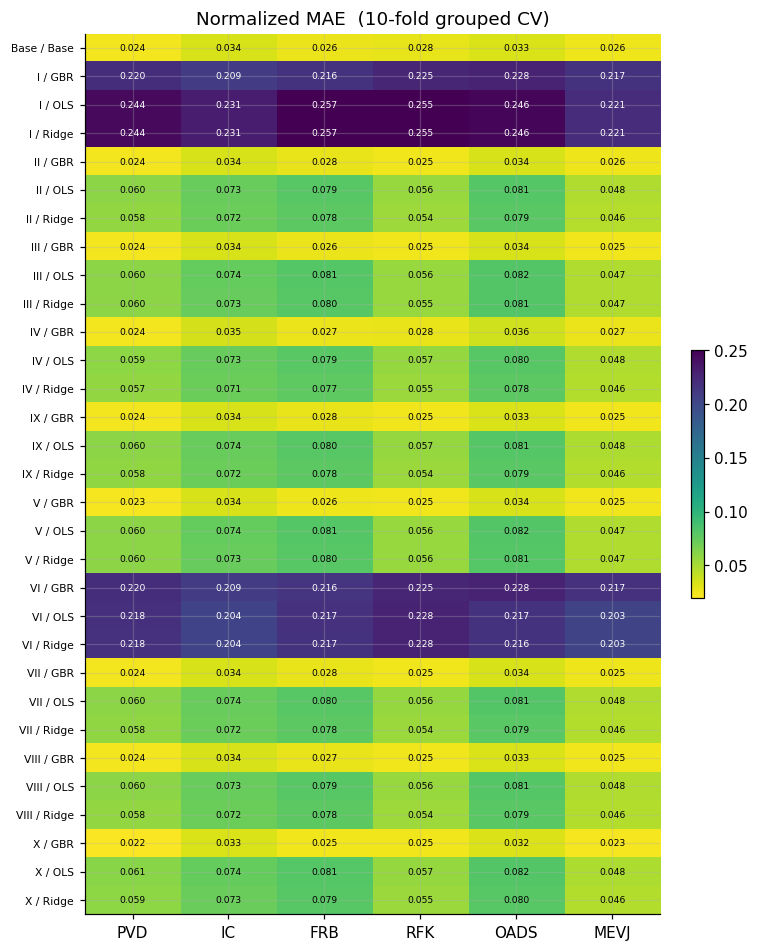

In [7]:
pvt = (model_grid.assign(fm=lambda d: d['feature'] + ' / ' + d['model'])
                 .pivot_table(index='fm', columns='policy',
                              values='mae_norm', aggfunc='first')
                 .reindex(columns=POLICY_ORDER))
# Keep only configurations computed for at least one policy
pvt = pvt.loc[pvt.notna().any(axis=1)]

fig, ax = plt.subplots(figsize=(7, 0.25 * len(pvt) + 1))
im = ax.imshow(pvt.to_numpy(), aspect='auto', cmap='viridis_r', vmin=0.02, vmax=0.25)
ax.set_xticks(range(len(pvt.columns))); ax.set_xticklabels(pvt.columns)
ax.set_yticks(range(len(pvt)));         ax.set_yticklabels(pvt.index, fontsize=7)
ax.set_title('Normalized MAE  (10-fold grouped CV)')
plt.colorbar(im, ax=ax, fraction=0.02)
for i in range(len(pvt)):
    for j in range(len(pvt.columns)):
        v = pvt.iat[i, j]
        if np.isfinite(v):
            ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=6,
                    color='white' if v > 0.13 else 'black')
plt.tight_layout()
plt.savefig('figB1_mae_heatmap.png', dpi=140, bbox_inches='tight')
plt.show()

## 8. Stage 1 — within-1-SE survivors

In [8]:
stage1 = nu.stage1_within_1se(model_grid)
n_survivors = int(stage1['within_1se'].sum())
print(f'Total candidates: {len(stage1)};  within-1-SE survivors: {n_survivors}')

survivor_summary = (stage1[stage1['within_1se']]
                     .groupby('policy')
                     .apply(lambda d: d.sort_values('mae_norm')[['feature','model','mae_norm','mae_norm_se']]
                                        .head(6).reset_index(drop=True),
                            include_groups=False))
survivor_summary

Total candidates: 186;  within-1-SE survivors: 26


feature model  mae_norm  mae_norm_se
policy                                       
FRB    0       X   GBR  0.025187     0.001028
       1       V   GBR  0.025504     0.001165
IC     0       X   GBR  0.032795     0.002360
       1     VII   GBR  0.033507     0.002106
       2      IX   GBR  0.033530     0.002208
       3     III   GBR  0.033552     0.002101
       4    VIII   GBR  0.033593     0.002134
       5      II   GBR  0.033718     0.002178
MEVJ   0       X   GBR  0.023345     0.000890
OADS   0       X   GBR  0.031772     0.002263
       1    Base  Base  0.032814     0.002286
       2      IX   GBR  0.033317     0.002035
       3    VIII   GBR  0.033412     0.002029
       4     III   GBR  0.033782     0.001719
       5     VII   GBR  0.034011     0.001651
PVD    0       X   GBR  0.021690     0.001490
RFK    0     VII   GBR  0.024652     0.001374
       1       V   GBR  0.024664     0.001600
       2       X   GBR  0.024673     0.001670
       3      IX   GBR  0.024840     0.001441
       4     III   GBR  0.024908     0.001396
       5      II   GBR  0.025037     0.001543

## 9. Stage 2 — final linear selection

For each policy, among within-1-SE linear (OLS / Ridge) candidates we
choose the one with the smallest $\dim(\phi)$, then smallest lag $\tau$,
then smallest standardized $\|\theta\|_1$.

In [9]:
selected = nu.stage2_select_linear(stage1, turns)
selected = selected[['policy','feature','model','alpha','dim_phi','lag',
                     'theta_l1','mae_norm','mae_norm_se','mae_dollar','rmse_norm',
                     'bias','r2']]
selected

,policy,feature,model,alpha,dim_phi,lag,theta_l1,mae_norm,mae_norm_se,mae_dollar,rmse_norm,bias,r2
0,FRB,IV,Ridge,10.0,3,1,2.278831,0.077450,0.004226,2341.422780,0.096865,-0.029872,0.877743
1,IC,IV,Ridge,10.0,3,1,1.860577,0.071251,0.003800,2044.867354,0.094670,-0.024729,0.864245
2,MEVJ,IV,Ridge,10.0,3,1,1.516033,0.046296,0.002630,1432.690087,0.059396,-0.009194,0.943857
3,OADS,IV,Ridge,10.0,3,1,2.024505,0.077617,0.005050,2418.144193,0.098595,-0.030079,0.863608
4,PVD,IV,Ridge,10.0,3,1,1.816176,0.056994,0.004997,1702.511614,0.073717,-0.020449,0.926169
5,RFK,IV,Ridge,10.0,3,1,1.899212,0.054785,0.001884,1435.453294,0.069092,-0.003592,0.941145


## 10. Selected-model diagnostics, per policy

For each policy we recover the held-out predictions from the Stage-2
winner and show the observed-vs-predicted scatter plus residual
distribution.

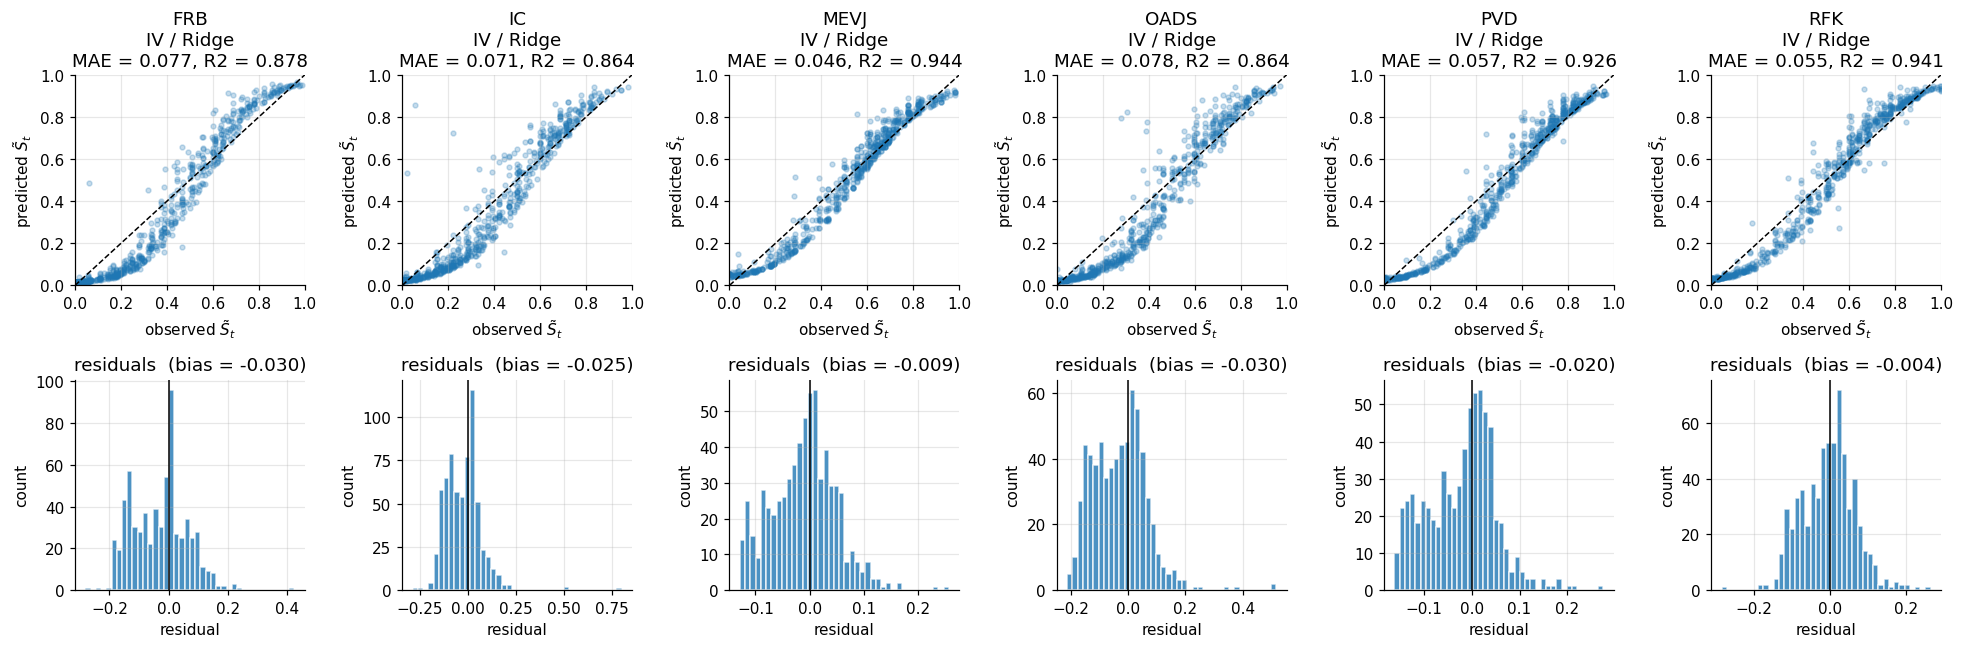

In [10]:
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i, row in enumerate(selected.itertuples(index=False)):
    pred_df = oof_store[(row.policy, row.feature, row.model)]
    title_top = f'{row.policy}\n{row.feature} / {row.model}\nMAE = {row.mae_norm:.3f}, R2 = {row.r2:.3f}'
    nu.pred_vs_actual_plot(pred_df['y_true'], pred_df['y_pred'],
                           title=title_top, ax=axes[0, i])
    nu.residual_hist(pred_df['y_true'], pred_df['y_pred'],
                     title=f'residuals  (bias = {row.bias:+.3f})',
                     ax=axes[1, i])
plt.tight_layout()
plt.savefig('figB2_selected_diagnostics.png', dpi=140, bbox_inches='tight')
plt.show()

## 11. Fitted coefficients for the selected linear models

Coefficients are reported on the **standardized** feature scale and the
**logit** target scale.  A positive coefficient means the feature
increases the seller's next normalized ask, holding everything else
fixed; a negative coefficient means it decreases it.

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge

coef_rows = []
for row in selected.itertuples(index=False):
    meta, X, y, cols = nu.build_design_matrix(turns, row.policy, row.feature)
    scaler = StandardScaler().fit(X)
    Xs = scaler.transform(X)
    y_logit = nu.logit_clip(y)
    if row.model == 'OLS':
        mdl = LinearRegression().fit(Xs, y_logit)
    else:
        a = row.alpha if np.isfinite(row.alpha) else 1.0
        mdl = Ridge(alpha=float(a)).fit(Xs, y_logit)
    for name, coef in zip(cols, mdl.coef_):
        coef_rows.append({'policy': row.policy, 'feature': row.feature,
                          'column': name, 'coef_std': float(coef)})
    coef_rows.append({'policy': row.policy, 'feature': row.feature,
                      'column': 'intercept', 'coef_std': float(mdl.intercept_)})

coef_tbl = (pd.DataFrame(coef_rows)
              .pivot_table(index='column', columns='policy',
                           values='coef_std', aggfunc='first')
              .reindex(columns=POLICY_ORDER))
coef_tbl.round(3)

policy,PVD,IC,FRB,RFK,OADS,MEVJ
column,,,,,,
A,0.066,0.080,0.084,0.050,-0.068,0.029
S_lag1,1.750,1.780,2.195,1.849,1.957,1.487
intercept,-0.218,-1.066,-1.275,-0.215,-0.993,-0.081


## 12. LaTeX export for the paper

Tables 3, 4, the Stage-2 selection table, and the coefficient table all
get written to `.tex` so they can be `\input{}`'d directly.

In [ ]:
from pathlib import Path
OUT_LATEX = Path('latex_tables'); OUT_LATEX.mkdir(exist_ok=True)

def df_to_booktabs(df, caption, label, index_name='Policy'):
    lines = []
    cols = df.columns.tolist()
    colfmt = 'l' + 'r' * len(cols)
    lines.append(r'\begin{table}[t]')
    lines.append(r'\centering')
    lines.append(r'\caption{' + caption + '}')
    lines.append(r'\label{' + label + '}')
    lines.append(r'\small')
    lines.append(r'\begin{tabular}{@{}' + colfmt + '@{}}')
    lines.append(r'\toprule')
    header_cells = [r'\textbf{' + index_name + '}'] + [r'\textbf{' + str(c) + '}' for c in cols]
    lines.append(' & '.join(header_cells) + r' \\')
    lines.append(r'\midrule')
    for idx, row in df.iterrows():
        vals = []
        for v in row:
            if isinstance(v, (int, np.integer)):
                vals.append(f'{int(v)}')
            elif isinstance(v, (float, np.floating)) and np.isfinite(v):
                vals.append(f'{v:.3g}')
            else:
                vals.append(str(v))
        lines.append(str(idx) + ' & ' + ' & '.join(vals) + r' \\')
    lines.append(r'\bottomrule')
    lines.append(r'\end{tabular}')
    lines.append(r'\end{table}')
    return '\n'.join(lines)

# Table 3
(OUT_LATEX / 'table3_turn_counts.tex').write_text(
    df_to_booktabs(table3.iloc[:-1],
                   'Pooled negotiation turns by policy and vehicle.',
                   'tab:turn-counts'))
# Stage-2 selected linear models
sel = selected.set_index('policy')[['feature', 'model', 'dim_phi', 'lag',
                                     'mae_norm', 'mae_dollar', 'r2']]
(OUT_LATEX / 'table_selected.tex').write_text(
    df_to_booktabs(sel,
                   'Stage-2 selected linear models per policy (v7 spec).',
                   'tab:selected'))

print('Wrote:')
for p in sorted(OUT_LATEX.glob('*.tex')):
    print(' ', p)

## 13. Persist selection for downstream notebooks

Exp 3–11 all consume the Stage-2 selected `(feature_name, model_name,
alpha)` per policy.  We save it to a CSV so other notebooks pick it up
without re-running the grid.

In [ ]:
selected.to_csv('selected_linear_models.csv', index=False)
print('Saved selected_linear_models.csv')
print(selected[['policy','feature','model','alpha','mae_norm','r2']])